In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

In [51]:
train_df = pd.read_csv('./train.csv')

In [52]:
test_df = pd.read_csv('./test.csv')

In [53]:
train_df.head()

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Без.ремонта,Дизайнерский,Евроремонт,...,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000,Детский.сад.1000,Бар.1000,Банк.1000,Аптека.1000,Цена
0,896,2,0,46.0,3,5,0,0,0,0,...,2,3,0,7,3,13,2,7,18,2350000.0
1,399,2,0,44.6,5,5,0,0,0,0,...,3,5,0,7,3,11,1,4,11,1799000.0
2,1515,2,0,53.0,1,9,0,1,0,0,...,4,11,0,5,3,17,3,7,15,2800000.0
3,1216,2,0,64.0,4,5,0,0,0,1,...,31,5,1,55,2,10,28,32,17,3970000.0
4,677,1,0,33.3,1,10,0,0,1,0,...,1,3,0,2,3,9,0,3,6,1880000.0


Таблица корреляции


In [54]:
corr = train_df.corr()
corr.style.background_gradient(cmap='coolwarm')

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Без.ремонта,Дизайнерский,Евроремонт,Косметический,Балкон,Лоджия,Совмещенный.санузел,Раздельный.санузел,Лифт,Грузовой.лифт,Мусоропровод,Год.постройки,Аварийный,Железобетонные.перекрытия,Смешанные.перекрытия,Деревянные.перекрытия,Иные.перекрытия,Панельные.стены,Блочные.стены,Деревянные.стены,Кирпичные.стены,Монолитные.стены,Смешанные.стены,Школа.1000,ВУЗ.1000,ТЦ.1000,Стоматология.1000,Почта.1000,Поликлиника.1000,Парк.1000,Остановка.1000,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000,Детский.сад.1000,Бар.1000,Банк.1000,Аптека.1000,Цена
id,1.000000,0.047893,-0.012322,0.070087,-0.013456,-0.001078,-0.011774,0.539269,-0.007047,-0.115848,-0.302281,0.051735,0.017318,-0.053954,0.070932,-0.027754,0.009182,-0.007412,0.017860,-0.004267,0.025348,-0.123232,0.048865,0.069547,-0.044551,0.047484,-0.042082,0.049124,-0.001523,-0.034868,-0.015266,0.049460,0.007808,-0.080975,-0.043388,-0.155971,0.119193,0.081536,0.026688,-0.133531,0.124719,0.082848,0.041024,-0.110447,0.020125,-0.016561,-0.077367,0.027728
Количество.комнат,0.047893,1.000000,-0.215494,0.828772,-0.080919,-0.120341,0.076310,0.056620,0.081681,0.101907,-0.144412,0.175734,0.091363,-0.292589,0.341588,0.016063,-0.090486,0.067288,-0.188166,-0.063752,-0.020230,-0.007109,0.044812,-0.043311,0.131384,-0.043393,-0.052021,-0.072520,-0.089867,-0.032425,0.224665,0.101228,0.113052,0.223164,0.189320,0.141152,0.092053,0.244324,0.181308,0.200743,0.044111,0.160463,0.036468,0.188885,0.161718,0.238145,0.224167,0.715229
Студия,-0.012322,-0.215494,1.000000,-0.285109,0.030731,0.039643,-0.030368,-0.048642,0.047618,0.013480,0.007677,-0.097190,-0.015284,0.203265,-0.181376,-0.024981,0.030988,-0.069179,0.014756,-0.012597,0.038043,-0.036872,-0.015290,-0.012597,-0.075265,-0.027401,0.115562,0.087962,-0.010987,-0.029329,-0.040688,-0.023025,-0.031498,-0.092036,-0.069635,-0.043049,-0.042693,-0.083491,-0.068389,-0.056225,-0.028758,-0.036229,0.009405,-0.062669,-0.077684,-0.064552,-0.088031,-0.263016
Общая.площадь,0.070087,0.828772,-0.285109,1.000000,0.099489,0.157488,0.129683,0.085246,0.089274,0.132984,-0.190216,0.266669,0.216605,-0.285701,0.370063,0.226503,0.059489,0.272344,0.121026,-0.060018,-0.010523,-0.008271,0.005885,0.050378,-0.030201,-0.060759,-0.061795,0.017639,0.053369,0.050301,0.067308,0.136521,0.114861,0.276077,0.132350,0.103474,0.064920,0.207154,0.205823,0.184813,0.058566,0.184605,-0.024588,0.209181,0.228194,0.223236,0.230283,0.938597
Этаж,-0.013456,-0.080919,0.030731,0.099489,1.000000,0.580705,0.099995,0.009407,-0.023093,0.012678,-0.007347,0.255515,0.159142,0.091520,-0.048368,0.367341,0.340632,0.352439,0.465650,-0.057847,0.129741,-0.052049,-0.163999,0.131647,-0.158655,-0.059372,-0.031740,0.096209,0.165492,0.067794,-0.237980,-0.074137,0.005574,0.005117,-0.188078,-0.125789,-0.053846,-0.110798,0.025116,-0.045302,0.008892,-0.006455,-0.124140,-0.033682,-0.003003,-0.075874,-0.056600,0.165215
Этажей.в.доме,-0.001078,-0.120341,0.039643,0.157488,0.580705,1.000000,0.213511,0.001102,-0.056517,-0.004936,0.023700,0.193552,0.166472,0.049052,-0.002560,0.625279,0.499806,0.595320,0.799497,-0.089107,0.275630,-0.131455,-0.273655,0.082195,-0.225507,-0.105992,-0.056985,0.110557,0.276522,0.149620,-0.386516,-0.040541,-0.025726,0.016620,-0.238690,-0.206616,-0.071681,-0.159559,-0.062014,-0.036335,-0.067238,-0.046274,-0.137629,-0.002114,0.011063,-0.155565,-0.094273,0.250635
Парковка,-0.011774,0.076310,-0.030368,0.129683,0.099995,0.213511,1.000000,-0.007869,0.003499,0.085976,-0.057539,0.012668,0.095559,0.040357,0.039982,0.140373,0.375648,0.162845,0.176520,-0.024868,0.016296,-0.011419,-0.004509,-0.024868,-0.081896,0.000202,-0.020292,0.080436,-0.012471,0.043803,-0.041491,0.023273,-0.033797,-0.014928,-0.013888,-0.072520,-0.015298,-0.034725,-0.028278,-0.012593,-0.032907,-0.021962,-0.012224,0.008763,-0.002512,-0.021565,-0.001355,0.155056
Без.ремонта,0.539269,0.056620,-0.048642,0.085246,0.009407,0.001102,-0.007869,1.000000,-0.053541,-0.112948,-0.618902,0.07

Признаки совмещенный и раздельный санузел коллинеарны, один из них можно удалить

Высокая корреляция стоматологии и аптеки

Высокая корреляция стоматологии и детского сада

Высокая корреляция аптеки и детского сада

Высокая корреляция одежды с банками и барами

Высокая корреляция года постройки с количеством этажей

Высокая корреляция вуза с кафе и тц

Крайне высокая корреляция кафе с банками и барами

Низкая корреляция Без ремонта и дизайнерский с итоговой переменной

Низкая корреляция Аварийный, смешанные железобетонные деревянные и иные перекрытия с итоговой переменной

Низкая корреляция стен с итоговой переменной

Удаление признаков с высокой корреляцией между собой и низкой корреляцией с итоговой переменной

In [55]:
train_df.drop(['Раздельный.санузел', 'Железобетонные.перекрытия', 'Смешанные.перекрытия', 'Деревянные.перекрытия', 'Иные.перекрытия',
'Панельные.стены', 'Блочные.стены', 'Деревянные.стены', 'Кирпичные.стены', 'Монолитные.стены', 'Смешанные.стены', 'Детский.сад.1000', 'Аптека.1000', 'Бар.1000', 	'Банк.1000',
               'ВУЗ.1000', 'Год.постройки', 	'Аварийный', 'Без.ремонта', 	'Дизайнерский'], axis=1, inplace=True)

In [56]:
test_df.drop(['Раздельный.санузел', 'Железобетонные.перекрытия', 'Смешанные.перекрытия', 'Деревянные.перекрытия', 'Иные.перекрытия',
'Панельные.стены', 'Блочные.стены', 'Деревянные.стены', 'Кирпичные.стены', 'Монолитные.стены', 'Смешанные.стены', 'Детский.сад.1000', 'Аптека.1000', 'Бар.1000', 	'Банк.1000',
               'ВУЗ.1000', 'Год.постройки', 	'Аварийный', 'Без.ремонта', 	'Дизайнерский'], axis=1, inplace=True)

test_df.head()

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Евроремонт,Косметический,Балкон,...,Стоматология.1000,Почта.1000,Поликлиника.1000,Парк.1000,Остановка.1000,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000
0,747,1,0,39.0,4,16,0,0,1,0,...,1,1,2,0,7,0,2,0,1,1
1,962,1,0,34.8,1,2,0,0,1,0,...,1,1,1,0,2,0,2,0,0,3
2,1105,1,0,37.7,2,17,0,0,1,0,...,9,1,0,1,5,2,9,0,9,3
3,795,4,0,83.5,10,10,0,0,1,1,...,13,3,1,2,13,47,5,1,19,2
4,390,1,0,42.0,10,10,0,0,1,1,...,12,2,2,2,20,8,8,0,7,2


In [57]:
train_df = train_df.drop(columns=['id'])

Удаление выбросов

In [58]:
# Вычисляем среднее и стандартное отклонение для каждого признака
mean = train_df.mean()
std_dev = train_df.std()

# Определяем границы для определения выбросов
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

# Удаляем выбросы
train_df = train_df[~((train_df < lower_bound) | (train_df > upper_bound)).any(axis=1)]

In [59]:
X = train_df.drop(columns=['Цена'])
y = train_df['Цена']

Разбиение выборки

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, test_size=0.3)

In [62]:
from sklearn import linear_model

In [63]:
from sklearn.preprocessing import PolynomialFeatures

In [64]:
from sklearn.preprocessing import SplineTransformer

In [65]:
from sklearn.kernel_ridge import KernelRidge

Создание моделей

In [66]:
poly = PolynomialFeatures()
spline = SplineTransformer()

In [67]:
lin_reg = linear_model.LinearRegression()
lasso = linear_model.Lasso()
ridge = linear_model.Ridge()
elastic_net = linear_model.ElasticNet()
lars = linear_model.Lars()
bayes = linear_model.BayesianRidge()
kernel_ridge = KernelRidge()
poly_reg = linear_model.LinearRegression()
spline_reg = linear_model.LinearRegression()

In [68]:
models = [lin_reg, lasso, ridge, elastic_net, lars, bayes, kernel_ridge]

Подбор параметров

In [69]:
params = [
    {'fit_intercept': [True, False]},
    {'alpha': [x for x in range(1,1000)]},
    {'alpha': [0.1, 0.5, 1.0]},
    {'alpha': [0.1, 0.5, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
    {'n_nonzero_coefs': [50, 100, 500]},
    {'alpha_1': [1e-6, 1e-5, 1e-4]},
    {'alpha': [0.1, 0.5, 1.0]}
]

In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [72]:
i = 0

In [73]:
for model in models:
  print(model)
  gs = GridSearchCV(model, params[i], cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
  gs.fit(X_train, y_train)
  y_pred = gs.predict(X_val)
  rmse = sqrt(mean_squared_error(y_val, y_pred))
  print(f"Best parameters for {model}: {gs.best_params_}")
  print(f"RMSE for {model}: {rmse}\n")
  i += 1

LinearRegression()
Best parameters for LinearRegression(): {'fit_intercept': True}
RMSE for LinearRegression(): 299866.0558721023

Lasso()
Best parameters for Lasso(): {'alpha': 836}
RMSE for Lasso(): 298954.931840818

Ridge()
Best parameters for Ridge(): {'alpha': 1.0}
RMSE for Ridge(): 299773.3113429983

ElasticNet()
Best parameters for ElasticNet(): {'alpha': 0.1, 'l1_ratio': 0.8}
RMSE for ElasticNet(): 300093.669455389

Lars()
Best parameters for Lars(): {'n_nonzero_coefs': 50}
RMSE for Lars(): 308551.1432254742

BayesianRidge()
Best parameters for BayesianRidge(): {'alpha_1': 0.0001}
RMSE for BayesianRidge(): 303172.8408263395

KernelRidge()
Best parameters for KernelRidge(): {'alpha': 1.0}
RMSE for KernelRidge(): 293456.7432757505



In [74]:
lin_reg = linear_model.LinearRegression(fit_intercept=True)
lasso = linear_model.Lasso(alpha=999)
ridge = linear_model.Ridge(alpha=1.0)
elastic_net = linear_model.ElasticNet(alpha=0.1, l1_ratio=0.8)
lars = linear_model.Lars(n_nonzero_coefs=50)
bayes = linear_model.BayesianRidge(alpha_1=0.0001)
kernel_ridge = KernelRidge(alpha=1.0)

In [75]:
models = [lin_reg, lasso, ridge, elastic_net, lars, bayes, kernel_ridge]

In [76]:
poly_features_train = poly.fit_transform(X_train)
poly_features_val = poly.fit_transform(X_val)

In [77]:
spline_train = spline.fit_transform(X_train)
spline_val = spline.fit_transform(X_val)

In [78]:
from sklearn.metrics import mean_squared_error

In [79]:
for model in models:
  estimator = model.fit(X_train, y_train)
  y_pred = estimator.predict(X_val)
  r2 = estimator.score(X_val, y_val)
  n = y_val.shape[0]
  p = X.shape[1]
  r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
  rmse = mean_squared_error(y_val, y_pred, squared=False)
  mse = mean_squared_error(y_val, y_pred)
  aic = n * np.log(mse) + 2 * p
  bic = n * np.log(mse) + p * np.log(n)
  try:
    coefs = estimator.coef_
    intercept = model.intercept_
  except Exception as err:
    coefs = None
    intercept = None

  print(f'Модель: {model}')
  print(f'RMSE: {rmse}')
  print(f'R2: {r2}')
  print(f'Adj R2: {r2_adj}')
  print(f'AIC: {aic}')
  print(f'BIC: {bic}')
  print(f'Коэффициенты: {coefs}')
  print(f'Смещение: {intercept}')
  print('\n\n')

Модель: LinearRegression()
RMSE: 299866.0558721023
R2: 0.8929687807371405
Adj R2: 0.8770669995895156
AIC: 5146.8808340980195
BIC: 5232.8957942304505
Коэффициенты: [-1.58350450e+05 -4.07453626e-10  5.50669707e+04 -5.15550064e+03
  9.45319656e+03  7.82616551e+04  3.08240857e+05  1.15124603e+05
  7.46362079e+04  1.36648848e+05  4.44530208e+04  1.29921591e+05
 -1.82613596e+04 -5.36206959e+04 -5.32060795e+03 -4.39217365e+04
  4.08302631e+03 -1.06550814e+04  2.85919745e+03  4.18538743e+04
  1.99446919e+04 -1.38971852e+03  1.21052404e+04 -4.24933770e+04
  1.73116218e+04 -1.47300614e+04]
Смещение: -342853.93214408075



Модель: Lasso(alpha=999)
RMSE: 298943.87008317537
R2: 0.8936260801948006
Adj R2: 0.8778219549665995
AIC: 5145.636488147447
BIC: 5231.651448279878
Коэффициенты: [-154502.42183346       0.           54938.87482078   -4210.66466728
    9494.27361214   66435.15541544  280950.70964168   96235.72457977
   66883.12349766  120026.87612964   39703.59411771  109853.75132616
      -0.    

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarnin

In [80]:
estimator = poly_reg.fit(poly_features_train, y_train)
y_pred = estimator.predict(poly_features_val)
r2 = estimator.score(poly_features_val, y_val)
n = y_val.shape[0]
p = X.shape[1]
r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
rmse = mean_squared_error(y_val, y_pred, squared=False)
mse = mean_squared_error(y_val, y_pred)
aic = n * np.log(mse) + 2 * p
bic = n * np.log(mse) + p * np.log(n)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'Adj R2: {r2_adj}')
print(f'AIC: {aic}')
print(f'BIC: {bic}')
print('\n\n')

RMSE: 899923.277952321
R2: 0.036022650848455906
Adj R2: -0.10719684102548777
AIC: 5590.866175949051
BIC: 5676.881136081482





C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [81]:
estimator = spline_reg.fit(spline_train, y_train)
y_pred = estimator.predict(spline_val)
r2 = estimator.score(spline_val, y_val)
n = y_val.shape[0]
p = X.shape[1]
r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
rmse = mean_squared_error(y_val, y_pred, squared=False)
mse = mean_squared_error(y_val, y_pred)
aic = n * np.log(mse) + 2 * p
bic = n * np.log(mse) + p * np.log(n)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'Adj R2: {r2_adj}')
print(f'AIC: {aic}')
print(f'BIC: {bic}')
print('\n\n')

RMSE: 2.638568348787827e+16
R2: -8.28690871633655e+20
Adj R2: -9.518106582763694e+20
AIC: 15327.885578200805
BIC: 15413.900538333237





C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [82]:
import statsmodels.api as sm

Отбор информативных признаков

In [83]:
X_stat = sm.add_constant(X)
model = sm.OLS(y, X_stat)
results = model.fit()

# Выводим статистику Стьюдента и p-value для каждого коэффициента
print(results.summary())

# Проверяем гипотезу о незначимости коэффициентов (p-value > |t|)
print("Гипотеза о незначимости коэффициентов:")
print(results.pvalues > np.abs(results.tvalues))

# Строим 95%-доверительный интервал для коэффициентов
print("95%-доверительный интервал для коэффициентов:")
print(results.conf_int(alpha=0.05))


                            OLS Regression Results                            
Dep. Variable:                   Цена   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     263.3
Date:                Wed, 20 Nov 2024   Prob (F-statistic):          1.75e-319
Time:                        12:58:13   Log-Likelihood:                -9422.9
No. Observations:                 673   AIC:                         1.890e+04
Df Residuals:                     647   BIC:                         1.902e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -2.401e+05   7

In [84]:
from sklearn.feature_selection import SelectKBest, chi2, f_regression, f_classif

In [85]:
selector = SelectKBest(chi2, k='all')
selector.fit(X, y)
X_selected = selector.transform(X)
scores = selector.scores_
for i in range(len(X.columns)):
  print(f'{X.columns[i]}: {scores[i]}')

Количество.комнат: 214.88213989130045
Студия: nan
Общая.площадь: 3874.663917099496
Этаж: 450.66511014100615
Этажей.в.доме: 454.24218635670076
Парковка: 163.03988949474092
Евроремонт: 194.07670578792766
Косметический: 35.33431898752374
Балкон: 113.47695502825351
Лоджия: 135.16177345194657
Совмещенный.санузел: 139.05223425622117
Лифт: 103.79454915445696
Грузовой.лифт: 185.2863193822895
Мусоропровод: 103.97513480551642
Школа.1000: 258.10313435305954
ТЦ.1000: 246.40077776816773
Стоматология.1000: 1019.8477126790029
Почта.1000: 119.91620484525903
Поликлиника.1000: 213.7229372454539
Парк.1000: 179.42197008993674
Остановка.1000: 500.251241971488
Одежда..1000: 2865.625102779176
Супер3кет.1000: 454.2757918837374
Кинотеатр.1000: 168.93974373743276
Кафе.1000: 901.5112410059131
АЗС.1000: 175.54591119526563


In [86]:
selector = SelectKBest(f_regression, k='all')
selector.fit(X, y)
X_selected = selector.transform(X)
scores = selector.scores_
for i in range(len(X.columns)):
  print(f'{X.columns[i]}: {scores[i]}')

Количество.комнат: 705.9153598825197
Студия: 0.0
Общая.площадь: 4119.075328725551
Этаж: 6.372700067339713
Этажей.в.доме: 27.69438249303232
Парковка: 16.68254247741222
Евроремонт: 17.767110919077396
Косметический: 23.28767735929787
Балкон: 41.934220284816526
Лоджия: 26.160571004274736
Совмещенный.санузел: 42.1019965930955
Лифт: 49.30452282333954
Грузовой.лифт: 4.773136710353719
Мусоропровод: 64.83629335564156
Школа.1000: 5.050056893025021
ТЦ.1000: 3.4892211860473994
Стоматология.1000: 73.03320490462636
Почта.1000: 17.938887423353112
Поликлиника.1000: 5.251322828942561
Парк.1000: 0.042709296408160784
Остановка.1000: 41.14984533491102
Одежда..1000: 32.359412876694655
Супер3кет.1000: 38.47725656743593
Кинотеатр.1000: 0.26443141928781005
Кафе.1000: 40.904845853845906
АЗС.1000: 3.412473490692297


In [87]:


drop1_train_df=train_df.copy(deep=True)
drop1_train_df.drop(['Косметический', 'Евроремонт', 'Студия', 'Этаж', 'Почта.1000', 'Кинотеатр.1000'], axis=1, inplace=True)

In [88]:
for model in models:
  estimator = model.fit(X_train, y_train)
  y_pred = estimator.predict(X_val)
  r2 = estimator.score(X_val, y_val)
  n = y_val.shape[0]
  p = X.shape[1]
  r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
  rmse = mean_squared_error(y_val, y_pred, squared=False)
  mse = mean_squared_error(y_val, y_pred)
  aic = n * np.log(mse) + 2 * p
  bic = n * np.log(mse) + p * np.log(n)

  print(f'Модель: {model}')
  print(f'RMSE: {rmse}')
  print(f'R2: {r2}')
  print(f'Adj R2: {r2_adj}')
  print(f'AIC: {aic}')
  print(f'BIC: {bic}')
  print('\n\n')

Модель: LinearRegression()
RMSE: 299866.0558721023
R2: 0.8929687807371405
Adj R2: 0.8770669995895156
AIC: 5146.8808340980195
BIC: 5232.8957942304505



Модель: Lasso(alpha=999)
RMSE: 298943.87008317537
R2: 0.8936260801948006
Adj R2: 0.8778219549665995
AIC: 5145.636488147447
BIC: 5231.651448279878



Модель: Ridge()
RMSE: 299773.3113429983
R2: 0.8930349771255612
Adj R2: 0.8771430308699303
AIC: 5146.755863016715
BIC: 5232.770823149146



Модель: ElasticNet(alpha=0.1, l1_ratio=0.8)
RMSE: 300093.669455389
R2: 0.8928062347952458
Adj R2: 0.8768803039648252
AIC: 5147.1873743145625
BIC: 5233.2023344469935



Модель: Lars(n_nonzero_coefs=50)
RMSE: 308551.1432254742
R2: 0.886679057566985
Adj R2: 0.8698428032626513
AIC: 5158.415727114397
BIC: 5244.430687246828



Модель: BayesianRidge(alpha_1=0.0001)
RMSE: 303172.8408263395
R2: 0.8905951829064723
Adj R2: 0.874340752938291
AIC: 5151.311574865407
BIC: 5237.326534997838



Модель: KernelRidge(alpha=1.0)
RMSE: 293456.7432757505
R2: 0.8974952372099239

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarnin

После отбора информативных признаков модель ухудшила свои показатели, поэтому решено вернуть эти признаки

Попробуем нормализацию

In [89]:
cols_to_normalize = ['Количество.комнат', 	'Общая.площадь', 'Этаж',	'Этажей.в.доме', 'Лифт',	'Грузовой.лифт',	'Мусоропровод',	'Школа.1000',	'ТЦ.1000',
                     'Стоматология.1000',	'Поликлиника.1000',	'Парк.1000',	'Остановка.1000',	'Одежда..1000',	'Супер3кет.1000',	'Кафе.1000']

In [90]:
X_train_norm = X_train.copy(deep=True)
X_val_norm = X_val.copy(deep=True)

In [91]:
X_train_norm

,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Евроремонт,Косметический,Балкон,Лоджия,...,Стоматология.1000,Почта.1000,Поликлиника.1000,Парк.1000,Остановка.1000,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000
259,1,0,39.0,4,10,0,0,1,1,0,...,2,1,1,0,2,1,3,0,2,3
752,2,0,44.3,2,5,0,0,1,1,0,...,5,2,3,0,9,5,5,0,2,5
167,4,0,83.0,2,10,1,0,1,1,0,...,2,1,1,0,2,1,3,0,2,3
603,1,0,33.8,14,14,1,0,1,0,1,...,7,1,1,1,5,2,9,0,7,2
160,3,0,61.0,2,4,0,0,0,0,0,...,6,2,1,1,8,1,1,0,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,4,0,82.0,6,10,0,0,1,0,0,...,28,5,4,1,11,14,10,0,7,2
227,3,0,65.0,5,9,1,0,1,1,0,...,7,3,1,1,12,5,3,0,5,3
695,2,0,56.0,6,9,0,1,0,1,0,...,14,3,3,2,6,22,4,0,9,1
529,4,0,80.0,5,5,0,0,0,2,0,...,18,3,5,0,14,46,9,0,24,5


In [92]:
X_train_norm[cols_to_normalize] = X_train_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_val_norm[cols_to_normalize] = X_val_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [93]:
for model in models:
  estimator = model.fit(X_train_norm, y_train)
  y_pred = estimator.predict(X_val_norm)
  r2 = estimator.score(X_val_norm, y_val)
  n = y_val.shape[0]
  p = X.shape[1]
  r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
  rmse = mean_squared_error(y_val, y_pred, squared=False)
  mse = mean_squared_error(y_val, y_pred)
  aic = n * np.log(mse) + 2 * p
  bic = n * np.log(mse) + p * np.log(n)

  print(f'Модель: {model}')
  print(f'RMSE: {rmse}')
  print(f'R2: {r2}')
  print(f'Adj R2: {r2_adj}')
  print(f'AIC: {aic}')
  print(f'BIC: {bic}')
  print('\n\n')

Модель: LinearRegression()
RMSE: 329425.6665310996
R2: 0.8708273038181028
Adj R2: 0.8516359318139353
AIC: 5184.862829142149
BIC: 5270.87778927458



Модель: Lasso(alpha=999)
RMSE: 321874.63370261836
R2: 0.8766811794939252
Adj R2: 0.8583595261615942
AIC: 5175.4946346048355
BIC: 5261.5095947372665



Модель: Ridge()
RMSE: 304630.88940829196
R2: 0.8895403316758197
Adj R2: 0.8731291809533701
AIC: 5153.249874114771
BIC: 5239.264834247202



Модель: ElasticNet(alpha=0.1, l1_ratio=0.8)
RMSE: 380784.3529776281
R2: 0.8274106288261791
Adj R2: 0.80176877939464
AIC: 5243.3953504389265
BIC: 5329.4103105713575



Модель: Lars(n_nonzero_coefs=50)
RMSE: 342788.5674392406
R2: 0.8601351718562552
Adj R2: 0.8393552545320417
AIC: 5200.9271223074165
BIC: 5286.942082439848



Модель: BayesianRidge(alpha_1=0.0001)
RMSE: 917008.7991429388
R2: -0.0009280586321309681
Adj R2: -0.1496373702003333
AIC: 5598.4644280943885
BIC: 5684.4793882268195



Модель: KernelRidge(alpha=1.0)
RMSE: 321474.0873644615
R2: 0.8769879

C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\ivans\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarnin

In [96]:
X_train = train_df.drop(columns=['Цена'])
y_train = train_df['Цена']

In [97]:
X_test = test_df.drop(columns=['id'])

In [98]:
original_test_df = pd.read_csv('./test.csv')

In [99]:
for model in models:
  estimator = model.fit(X_train, y_train)
  y_pred = estimator.predict(X_test)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}.csv', index=False)

In [100]:
X_train_norm = X_train.copy(deep=True)
X_test_norm = X_test.copy(deep=True)

In [101]:
X_train_norm[cols_to_normalize] = X_train_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_test_norm[cols_to_normalize] = X_test_norm[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [102]:
for model in models:
  estimator = model.fit(X_train_norm, y_train)
  y_pred = estimator.predict(X_test_norm)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_normalized.csv', index=False)

С отбором признаков

In [103]:
X_train_selected = X_train.copy(deep=True)
X_test_selected = X_test.copy(deep=True)

In [104]:
X_train_selected.drop(['Косметический', 'Евроремонт', 'Студия', 'Этаж', 'Почта.1000', 'Кинотеатр.1000'], axis=1, inplace=True)
X_test_selected.drop(['Косметический', 'Евроремонт', 'Студия', 'Этаж', 'Почта.1000', 'Кинотеатр.1000'], axis=1, inplace=True)

In [105]:
for model in models:
  estimator = model.fit(X_train_selected, y_train)
  y_pred = estimator.predict(X_test_selected)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_selected.csv', index=False)

Оверсэмплинг

In [106]:
from imblearn.over_sampling import RandomOverSampler

In [107]:
ros = RandomOverSampler(random_state=0)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [108]:
for model in models:
  estimator = model.fit(X_resampled, y_resampled)
  y_pred = estimator.predict(X_test)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_oversampled.csv', index=False)

Оригинальный датасет

In [109]:
for model in models:
  estimator = model.fit(X_train, y_train)
  y_pred = estimator.predict(X_test)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_orig.csv', index=False)

Датасет без выбросов

In [110]:
for model in models:
  estimator = model.fit(X, y)
  y_pred = estimator.predict(X_test)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_no_out.csv', index=False)

Оригинальный датасет без выбросов

In [111]:
for model in models:
  estimator = model.fit(X, y)
  y_pred = estimator.predict(X_test)
  output = pd.DataFrame({'id': original_test_df['id'], 'Цена': y_pred})
  output.to_csv(f'./output_{model}_orig_no_out.csv', index=False)

Лучший score

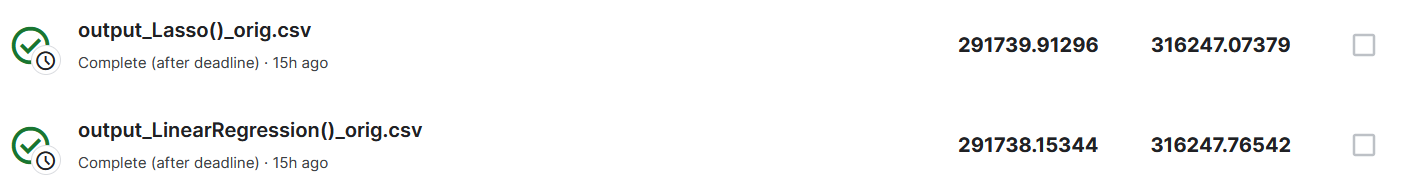